In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
data = pd.read_csv("bitcoin_price_data.csv")

In [3]:
data['Date'] = pd.to_datetime(data['Date'], errors='coerce')
data.set_index('Date', inplace=True)
data = data.sort_index()

In [4]:
# Remove commas and convert to numeric
data['Close'] = data['Close'].astype(str).str.replace(',', '')
data['Close'] = pd.to_numeric(data['Close'], errors='coerce')

# Optional: convert other columns too
for col in ['Open', 'High', 'Low', 'Volume']:
    if col in data.columns:
        data[col] = data[col].astype(str).str.replace(',', '')
        data[col] = pd.to_numeric(data[col], errors='coerce')

# Drop missing rows
data.dropna(inplace=True)

In [5]:
print(data.dtypes)

Open                  float64
High                  float64
Low                   float64
Close                 float64
percent_change_24h    float64
Volume                  int64
Market Cap             object
dtype: object


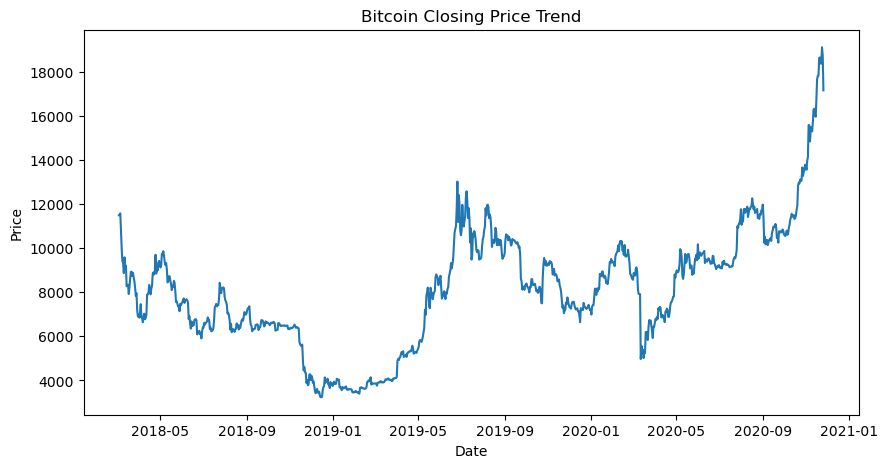

In [6]:
plt.figure(figsize=(10,5))
plt.plot(data['Close'])
plt.title("Bitcoin Closing Price Trend")
plt.xlabel("Date")
plt.ylabel("Price")
plt.show()

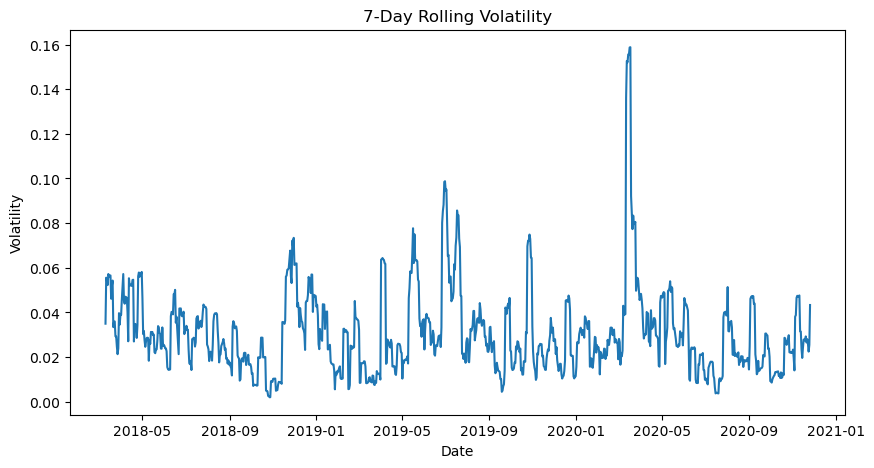

In [7]:
data['Returns'] = data['Close'].pct_change()
data['Volatility'] = data['Returns'].rolling(7).std()

plt.figure(figsize=(10,5))
plt.plot(data['Volatility'])
plt.title("7-Day Rolling Volatility")
plt.xlabel("Date")
plt.ylabel("Volatility")
plt.show()